# Tarea 5: Modelos de Clasificación (MDS, Primavera 2025)
Nombre: Patricio Espinoza A.

In [2]:
# a
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math


# b
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, Isomap
import umap.umap_ as umap

# d
from sklearn.model_selection import train_test_split

# e
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# f
from sklearn.metrics import roc_curve, roc_auc_score

# g
from sklearn.model_selection import GridSearchCV

# j
from sklearn.preprocessing import RobustScaler, StandardScaler

## Parte (a): Análisis Exploratorio

In [58]:
# Cargar datos
df = pd.read_csv("data.csv")  

print(df.info())
print(df["diagnosis"].value_counts())

# variable diagnosis a dummy binario
df["diagnosis"] = df["diagnosis"].map({"M": 1, "B": 0})

# Eliminar columna no informativa
df = df.drop(columns=['Unnamed: 32'])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5


🔹 Variables '_mean' — Clase BENIGNA:


,count,mean,std,min,25%,50%,75%,max
radius_mean,357.0,12.146524,1.780512,6.98100,11.08000,12.20000,13.37000,17.85000
texture_mean,357.0,17.914762,3.995125,9.71000,15.15000,17.39000,19.76000,33.81000
perimeter_mean,357.0,78.075406,11.807438,43.79000,70.87000,78.18000,86.10000,114.60000
area_mean,357.0,462.790196,134.287118,143.50000,378.20000,458.40000,551.10000,992.10000
smoothness_mean,357.0,0.092478,0.013446,0.05263,0.08306,0.09076,0.10070,0.16340
compactness_mean,357.0,0.080085,0.033750,0.01938,0.05562,0.07529,0.09755,0.22390
concavity_mean,357.0,0.046058,0.043442,0.00000,0.02031,0.03709,0.05999,0.41080
concave points_mean,357.0,0.025717,0.015909,0.00000,0.01502,0.02344,0.03251,0.08534
symmetry_mean,357.0,0.174186,0.024807,0.10600,0.15800,0.17140,0.18900,0.27430
fractal_dimension_mean,357.0,0.062867,0.006747,0.05185,0.05853,0.06154,0.06576,0.09575



🔹 Variables '_mean' — Clase MALIGNA:


,count,mean,std,min,25%,50%,75%,max
radius_mean,212.0,17.462830,3.203971,10.95000,15.075000,17.325000,19.590000,28.11000
texture_mean,212.0,21.604906,3.779470,10.38000,19.327500,21.460000,23.765000,39.28000
perimeter_mean,212.0,115.365377,21.854653,71.90000,98.745000,114.200000,129.925000,188.50000
area_mean,212.0,978.376415,367.937978,361.60000,705.300000,932.000000,1203.750000,2501.00000
smoothness_mean,212.0,0.102898,0.012608,0.07371,0.094010,0.102200,0.110925,0.14470
compactness_mean,212.0,0.145188,0.053987,0.04605,0.109600,0.132350,0.172400,0.34540
concavity_mean,212.0,0.160775,0.075019,0.02398,0.109525,0.151350,0.203050,0.42680
concave points_mean,212.0,0.087990,0.034374,0.02031,0.064620,0.086280,0.103175,0.20120
symmetry_mean,212.0,0.192909,0.027638,0.13080,0.174050,0.189900,0.209850,0.30400
fractal_dimension_mean,212.0,0.062680,0.007573,0.04996,0.056598,0.061575,0.067075,0.09744



🔹 Variables '_se' — Clase BENIGNA:


...

,count,mean,std,min,25%,50%,75%,max
radius_se,212.0,0.609083,0.345039,0.193800,0.390375,0.547200,0.757300,2.87300
texture_se,212.0,1.210915,0.483178,0.362100,0.892825,1.102500,1.429250,3.56800
perimeter_se,212.0,4.323929,2.568546,1.334000,2.715500,3.679500,5.206250,21.98000
area_se,212.0,72.672406,61.355268,13.990000,35.762500,58.455000,94.000000,542.20000
smoothness_se,212.0,0.006780,0.002890,0.002667,0.005085,0.006209,0.007971,0.03113
compactness_se,212.0,0.032281,0.018387,0.008422,0.019662,0.028590,0.038910,0.13540
concavity_se,212.0,0.041824,0.021603,0.011010,0.026998,0.037125,0.050443,0.14380
concave points_se,212.0,0.015060,0.005517,0.005174,0.011415,0.014205,0.017497,0.04090
symmetry_se,212.0,0.020472,0.010065,0.007882,0.014615,0.017700,0.022132,0.07895
fractal_dimension_se,212.0,0.004062,0.002041,0.001087,0.002688,0.003739,0.004892,0.01284



🔹 Variables '_worst' — Clase BENIGNA:


,count,mean,std,min,25%,50%,75%,max
radius_worst,357.0,13.379801,1.981368,7.93000,12.08000,13.35000,14.80000,19.8200
texture_worst,357.0,23.515070,5.493955,12.02000,19.58000,22.82000,26.51000,41.7800
perimeter_worst,357.0,87.005938,13.527091,50.41000,78.27000,86.92000,96.59000,127.1000
area_worst,357.0,558.899440,163.601424,185.20000,447.10000,547.40000,670.00000,1210.0000
smoothness_worst,357.0,0.124959,0.020013,0.07117,0.11040,0.12540,0.13760,0.2006
compactness_worst,357.0,0.182673,0.092180,0.02729,0.11200,0.16980,0.23020,0.5849
concavity_worst,357.0,0.166238,0.140368,0.00000,0.07708,0.14120,0.22160,1.2520
concave points_worst,357.0,0.074444,0.035797,0.00000,0.05104,0.07431,0.09749,0.1750
symmetry_worst,357.0,0.270246,0.041745,0.15660,0.24060,0.26870,0.29830,0.4228
fractal_dimension_worst,357.0,0.079442,0.013804,0.05521,0.07009,0.07712,0.08541,0.1486



🔹 Variables '_worst' — Clase MALIGNA:


,count,mean,std,min,25%,50%,75%,max
radius_worst,212.0,21.134811,4.283569,12.84000,17.730000,20.59000,23.807500,36.0400
texture_worst,212.0,29.318208,5.434804,16.67000,25.782500,28.94500,32.690000,49.5400
perimeter_worst,212.0,141.370330,29.457055,85.10000,119.325000,138.00000,159.800000,251.2000
area_worst,212.0,1422.286321,597.967743,508.10000,970.300000,1303.00000,1712.750000,4254.0000
smoothness_worst,212.0,0.144845,0.021870,0.08822,0.130475,0.14345,0.155975,0.2226
compactness_worst,212.0,0.374824,0.170372,0.05131,0.244475,0.35635,0.447850,1.0580
concavity_worst,212.0,0.450606,0.181507,0.02398,0.326425,0.40490,0.556175,1.1700
concave points_worst,212.0,0.182237,0.046308,0.02899,0.152750,0.18200,0.210675,0.2910
symmetry_worst,212.0,0.323468,0.074685,0.15650,0.276500,0.31030,0.359225,0.6638
fractal_dimension_worst,212.0,0.091530,0.021553,0.05504,0.076302,0.08760,0.102625,0.2075


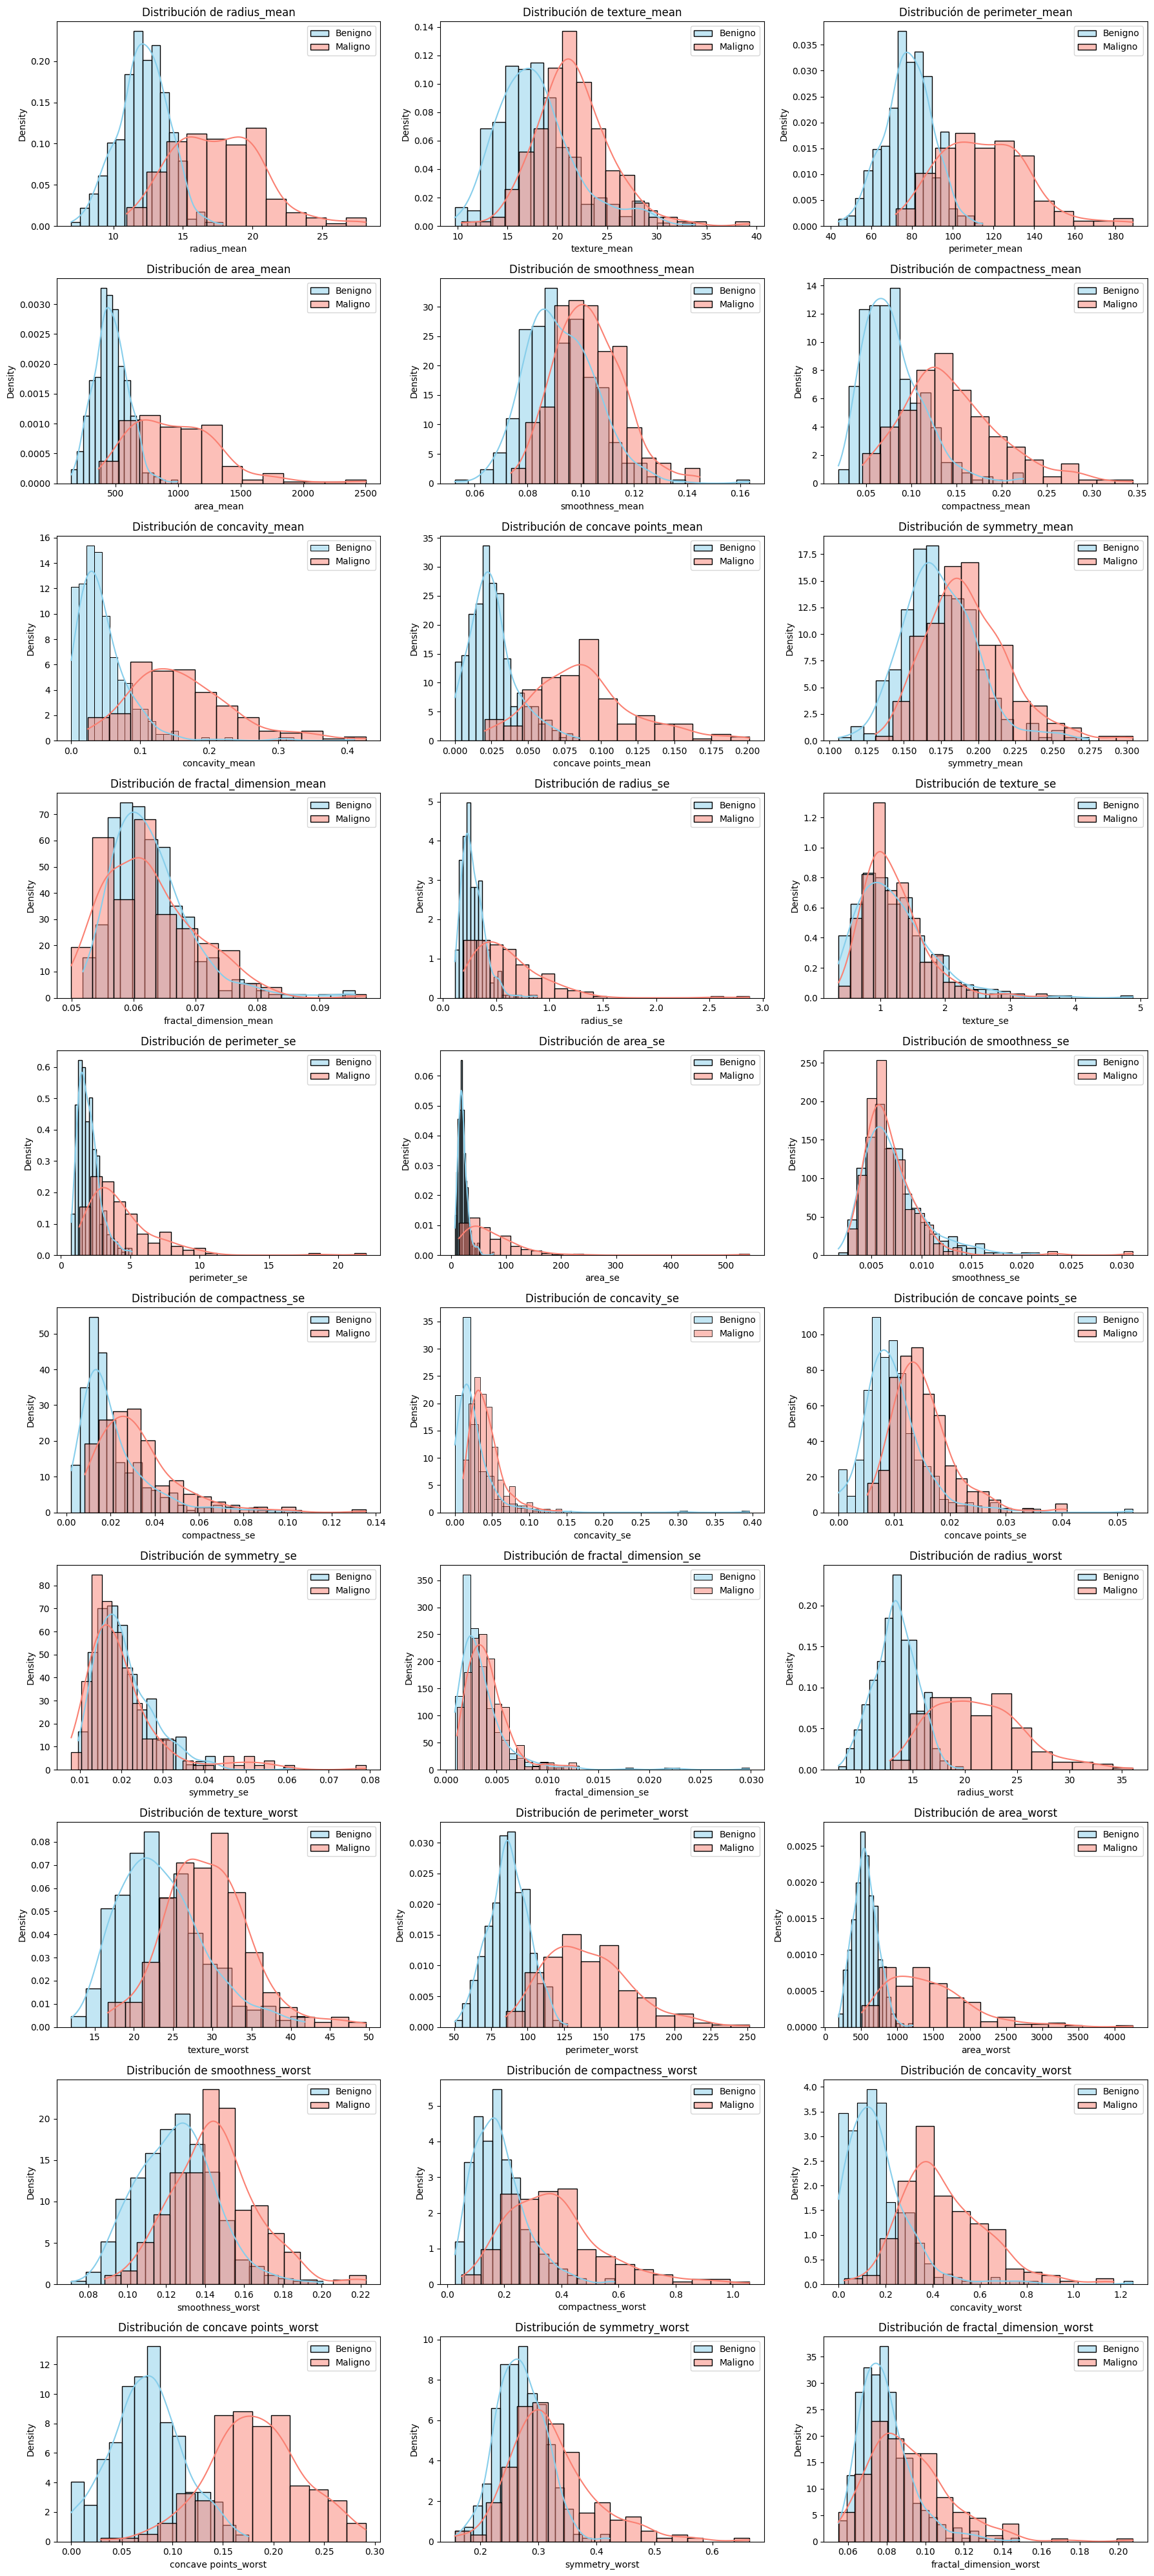

In [ ]:
# Separar las clases (quitamos id y diagnosis)
df_benign = df[df["diagnosis"] == 0].drop(columns=["id", "diagnosis"])
df_malign = df[df["diagnosis"] == 1].drop(columns=["id", "diagnosis"])

# Separar columnas por tipo de variable
cols_mean = [c for c in df_benign.columns if c.endswith("_mean")]
cols_se = [c for c in df_benign.columns if c.endswith("_se")]
cols_worst = [c for c in df_benign.columns if c.endswith("_worst")]

# Estadísticas descriptivas para cada tipo de variable y clase
desc_mean_benign = df_benign[cols_mean].describe().T
desc_mean_malign = df_malign[cols_mean].describe().T

desc_se_benign = df_benign[cols_se].describe().T
desc_se_malign = df_malign[cols_se].describe().T

desc_worst_benign = df_benign[cols_worst].describe().T
desc_worst_malign = df_malign[cols_worst].describe().T

# Mostrar resultados
print("\n🔹 Variables '_mean' — Clase BENIGNA:")
display(desc_mean_benign)
print("\n🔹 Variables '_mean' — Clase MALIGNA:")
display(desc_mean_malign)

print("\n🔹 Variables '_se' — Clase BENIGNA:")
display(desc_se_benign)
print("\n🔹 Variables '_se' — Clase MALIGNA:")
display(desc_se_malign)

print("\n🔹 Variables '_worst' — Clase BENIGNA:")
display(desc_worst_benign)
print("\n🔹 Variables '_worst' — Clase MALIGNA:")
display(desc_worst_malign)


# Histograma para variables continuas
variables = df.columns.drop(["diagnosis", "id"])

n_cols = 3  # cantidad de columnas en la cuadrícula
n_rows = math.ceil(len(variables) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(variables):
    sns.histplot(df_benign[col], color="skyblue", label="Benigno", kde=True, stat="density", ax=axes[i])
    sns.histplot(df_malign[col], color="salmon", label="Maligno", kde=True, stat="density", ax=axes[i])
    axes[i].set_title(f"Distribución de {col}")
    axes[i].legend()

# Quitar ejes vacíos (si sobran)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Parte (b): Reducción de dimensionalidad

In [60]:
# Cargar datos
df = pd.read_csv("data.csv")  
# variable diagnosis a dummy binario
df["diagnosis"] = df["diagnosis"].map({"M": 1, "B": 0})

# Eliminar columna no informativa
df = df.drop(columns=['Unnamed: 32'])

c:\Users\pbast\Desktop\Universidad\VIV Semestre\Aprendizaje de Máquinas\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\pbast\Desktop\Universidad\VIV Semestre\Aprendizaje de Máquinas\venv\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
c:\Users\pbast\Desktop\Universidad\VIV Semestre\Aprendizaje de Máquinas\venv\Lib\site-packages\sklearn\manifold\_isomap.py:384: UserWarning: The number of connected components of the neighbors graph is 15 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
c:\Users\pbast\Desktop\Universidad\VIV Semestre\Aprendizaje de Máquinas\venv\Lib\site-packages\scipy\sparse\_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix

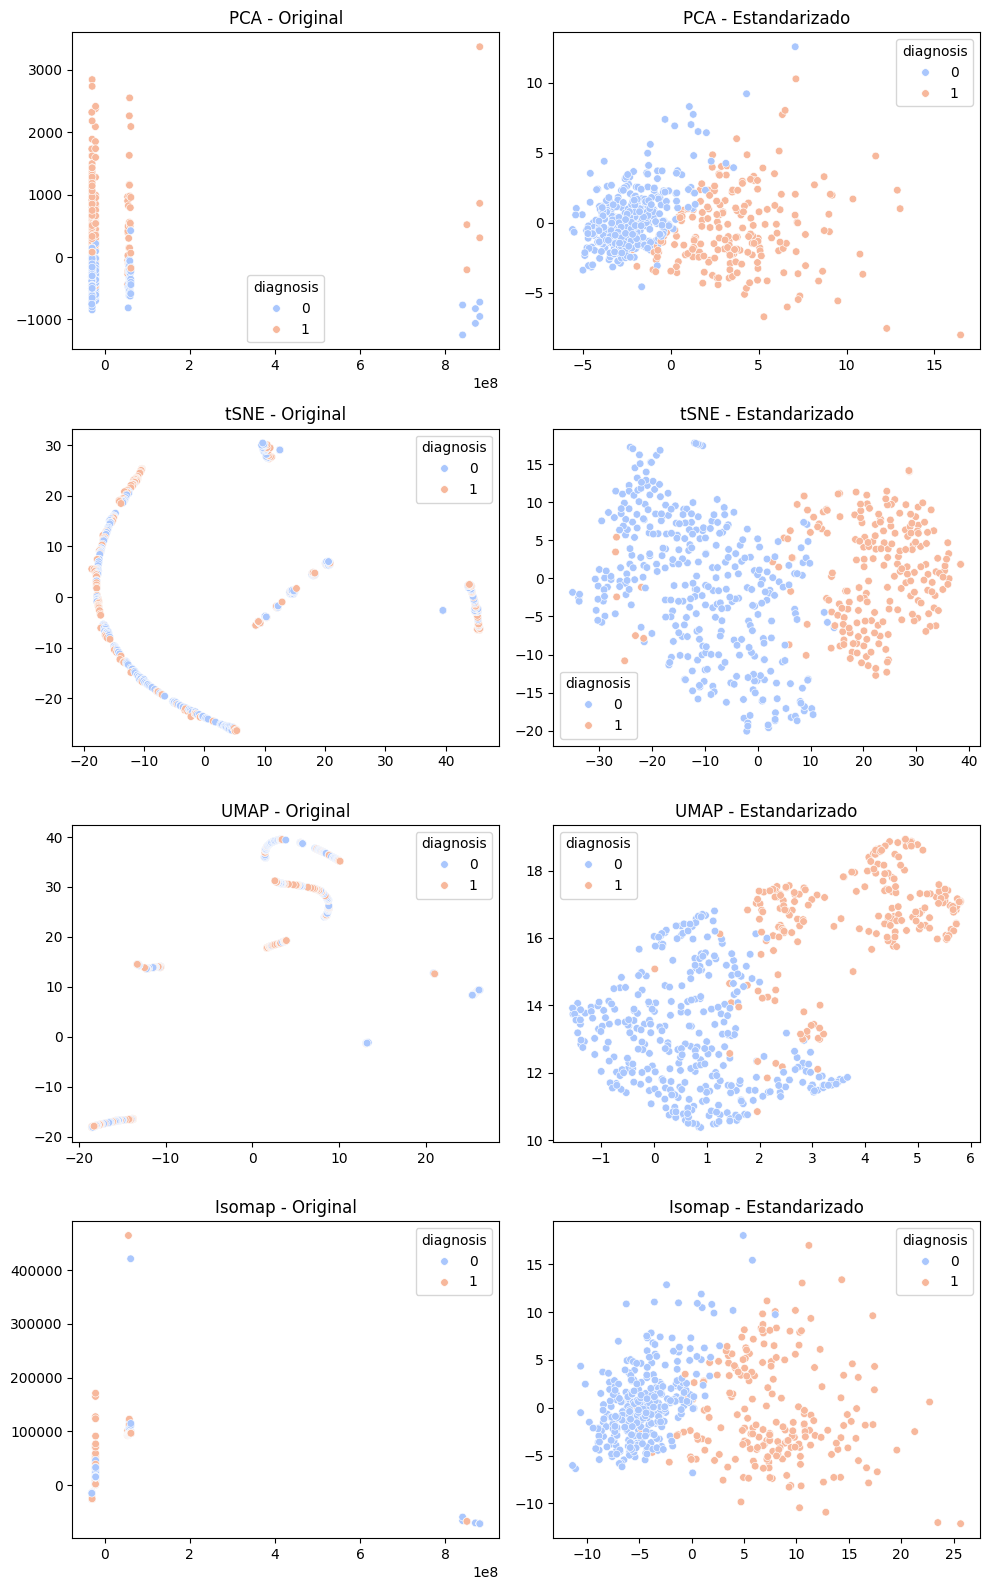

In [61]:
X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

# Versión estandarizada
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

# Métodos de reducción
d = 2
reducers = {
    "PCA": PCA(n_components=d),
    "tSNE": TSNE(n_components=d, random_state=42),
    "UMAP": umap.UMAP(n_components=d, random_state=42),
    "Isomap": Isomap(n_components=d)
}

# Graficar proyecciones
fig, axes = plt.subplots(4, 2, figsize=(10, 16))
for i, (name, model) in enumerate(reducers.items()):
    X_proj = model.fit_transform(X)
    X_proj_std = model.fit_transform(X_std)
    sns.scatterplot(x=X_proj[:, 0], y=X_proj[:, 1], hue=y, ax=axes[i, 0], palette="coolwarm", s=30)
    sns.scatterplot(x=X_proj_std[:, 0], y=X_proj_std[:, 1], hue=y, ax=axes[i, 1], palette="coolwarm", s=30)
    axes[i, 0].set_title(f"{name} - Original")
    axes[i, 1].set_title(f"{name} - Estandarizado")
plt.tight_layout()
plt.show()

## Parte (c): Matriz de correlaciones

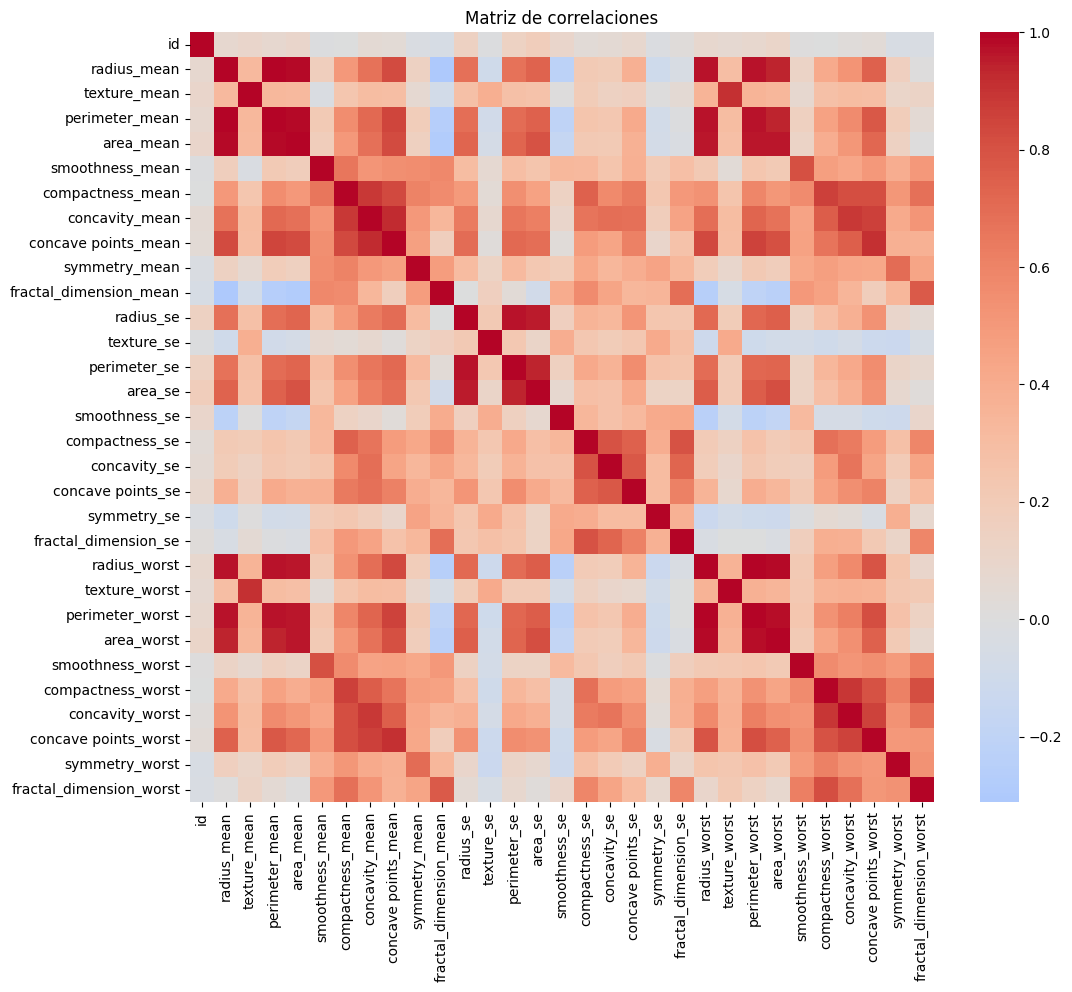

In [62]:
plt.figure(figsize=(12,10))
sns.heatmap(df.drop(columns="diagnosis").corr(), cmap="coolwarm", center=0)
plt.title("Matriz de correlaciones")
plt.show()


Top correlaciones - _mean


Correlación
radius_mean      perimeter_mean          0.997855
                 area_mean               0.987357
perimeter_mean   area_mean               0.986507
concavity_mean   concave points_mean     0.921391
compactness_mean concavity_mean          0.883121


Top correlaciones - _se


Correlación
radius_se      perimeter_se             0.972794
               area_se                  0.951830
perimeter_se   area_se                  0.937655
compactness_se fractal_dimension_se     0.803269
               concavity_se             0.801268


Top correlaciones - _worst


Correlación
radius_worst      perimeter_worst          0.993708
                  area_worst               0.984015
perimeter_worst   area_worst               0.977578
compactness_worst concavity_worst          0.892261
concavity_worst   concave points_worst     0.855434

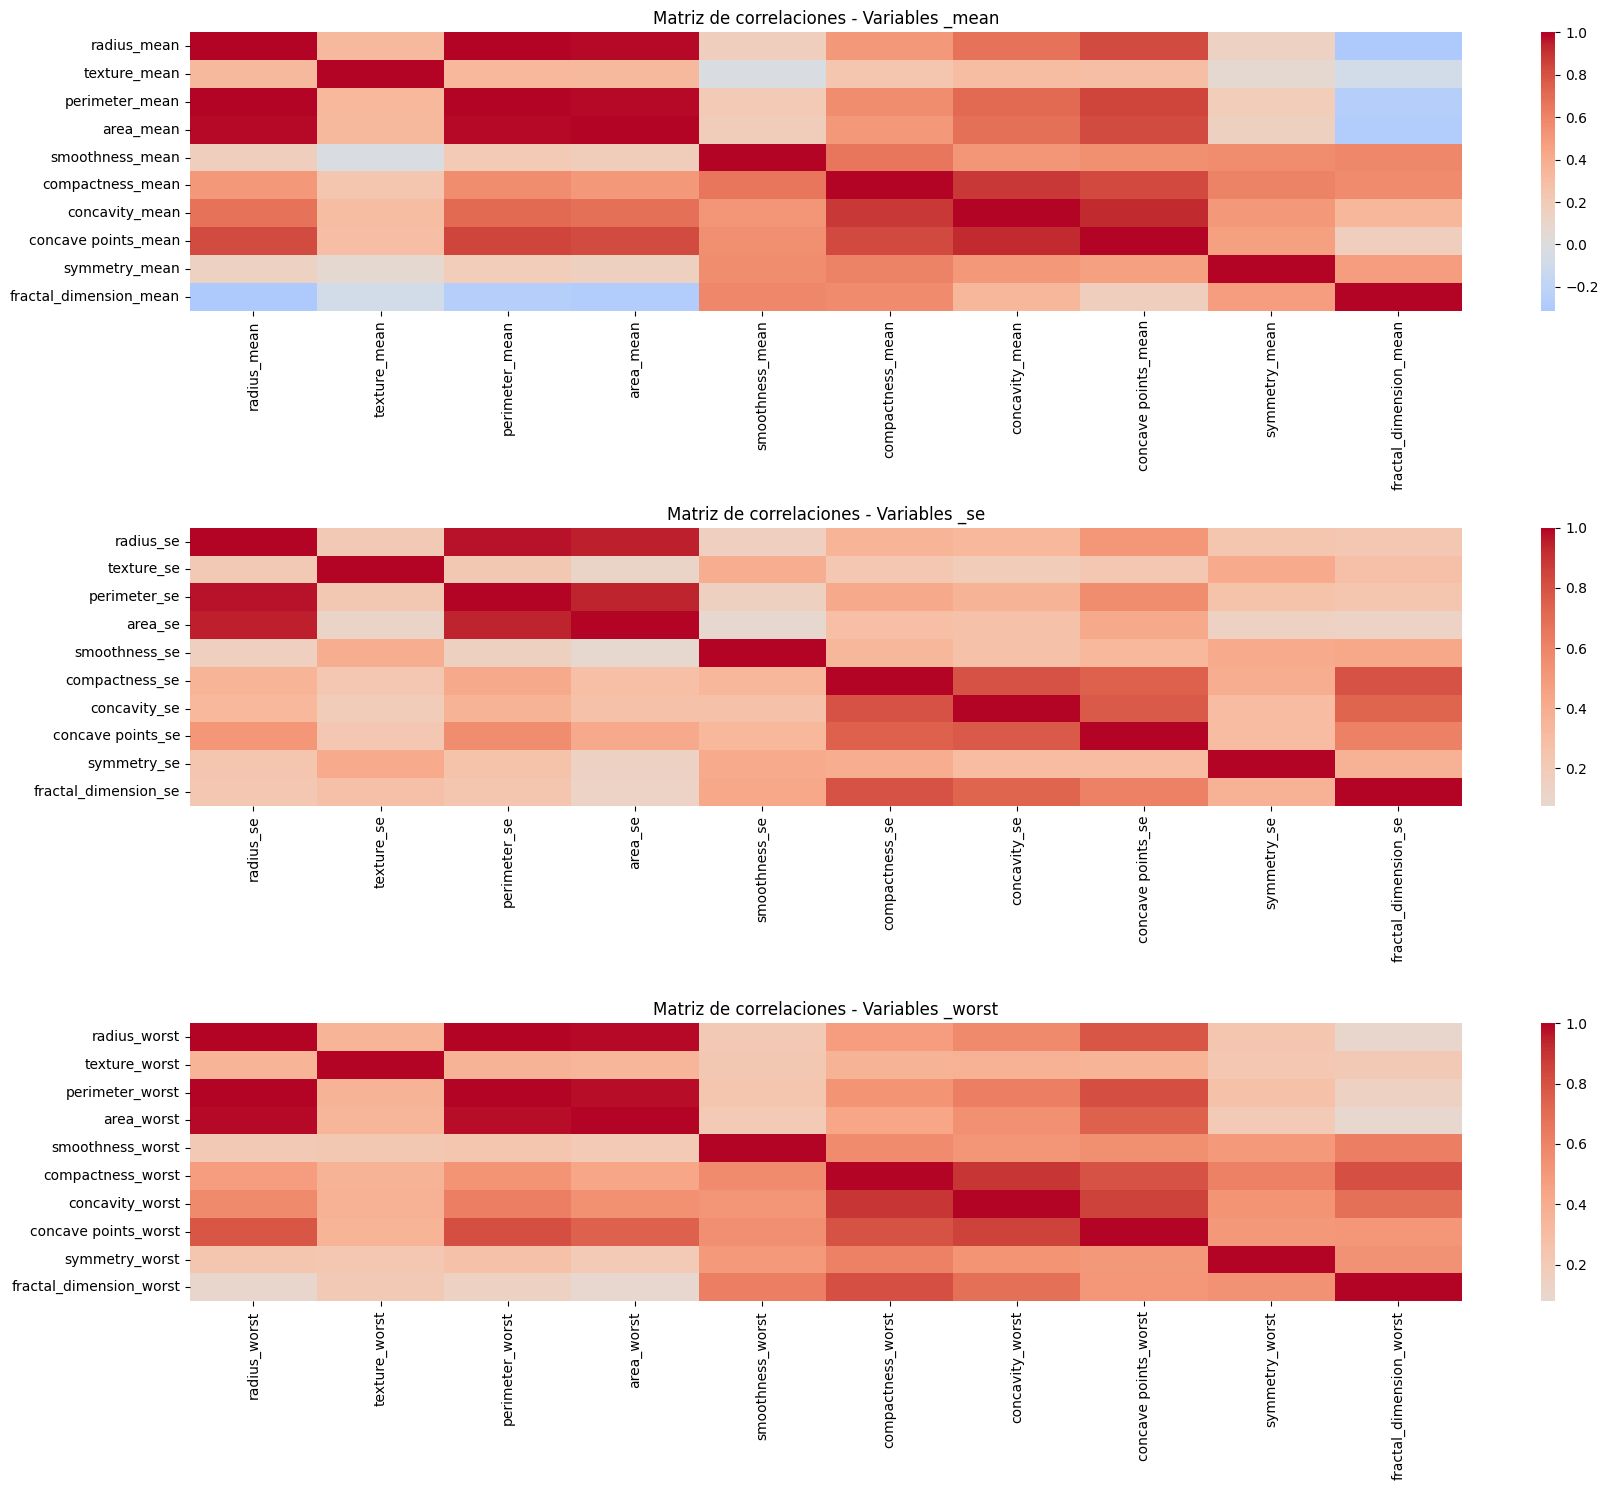

In [ ]:
# Separar las columnas según el tip
mean_cols = [c for c in df.columns if c.endswith('_mean')]
se_cols = [c for c in df.columns if c.endswith('_se')]
worst_cols = [c for c in df.columns if c.endswith('_worst')]

corr_mean = df[mean_cols].corr()
corr_se = df[se_cols].corr()
corr_worst = df[worst_cols].corr()

def mostrar_top_correlaciones(corr_matrix, titulo):
    corr_pairs = (
        corr_matrix.where(~np.tril(np.ones(corr_matrix.shape)).astype(bool))
        .stack()
        .sort_values(ascending=False)
    )
    print(f"\n{'='*20}\n{titulo}\n{'='*20}")
    display(corr_pairs.to_frame("Correlación").head(5)) 

import numpy as np
mostrar_top_correlaciones(corr_mean, "Top correlaciones - _mean")
mostrar_top_correlaciones(corr_se, "Top correlaciones - _se")
mostrar_top_correlaciones(corr_worst, "Top correlaciones - _worst")

plt.figure(figsize=(18, 15))

plt.subplot(3, 1, 1)
sns.heatmap(corr_mean, cmap="coolwarm", center=0, annot=False)
plt.title("Matriz de correlaciones - Variables _mean")

plt.subplot(3, 1, 2)
sns.heatmap(corr_se, cmap="coolwarm", center=0, annot=False)
plt.title("Matriz de correlaciones - Variables _se")

plt.subplot(3, 1, 3)
sns.heatmap(corr_worst, cmap="coolwarm", center=0, annot=False)
plt.title("Matriz de correlaciones - Variables _worst")

plt.tight_layout()
plt.show()

## Parte (d): División de datos

In [3]:
# Cargar datos
df = pd.read_csv("data.csv")  
# variable diagnosis a dummy binario
df["diagnosis"] = df["diagnosis"].map({"M": 1, "B": 0})

# Eliminar columna no informativa
df = df.drop(columns=['Unnamed: 32'])

X = df.drop(columns=["diagnosis", "id"])
y = df["diagnosis"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [5]:
# Estandarizar
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [6]:
# Tamaño de los conjuntos (X e Y por clase)
print("Tamaños de los conjuntos de entrenamiento y prueba:")
print(f"Conjunto de entrenamiento: {X_train.shape[0]} muestras")
print(f"Distribución de clases en entrenamiento:")
print(y_train.value_counts(normalize=False))
print(f"Conjunto de prueba: {X_test.shape[0]} muestras")
print(f"Distribución de clases en prueba:")
print(y_test.value_counts(normalize=False))


Tamaños de los conjuntos de entrenamiento y prueba:
Conjunto de entrenamiento: 455 muestras
Distribución de clases en entrenamiento:
diagnosis
0    285
1    170
Name: count, dtype: int64
Conjunto de prueba: 114 muestras
Distribución de clases en prueba:
diagnosis
0    72
1    42
Name: count, dtype: int64


## Parte (e): Modelo SVC por defecto

In [7]:
svc = SVC()  # parámetros por defecto: kernel='rbf', C=1, gamma='scale'
svc.fit(X_train, y_train)

y_pred_train = svc.predict(X_train)
y_pred_test = svc.predict(X_test)

def metrics_report(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    spec = tn / (tn + fp)
    fpr = fp / (fp + tn)
    fnr = fn / (fn + tp)

    from sklearn.metrics import classification_report
    print(classification_report(y_true, y_pred))

    # AUC
    auc = roc_auc_score(y_true, y_pred)
    print(f"AUC: {auc:.4f}")

    return {
        "Accuracy": acc,
        "Precision": prec,
        "Recall (Sensibilidad)": rec,
        "Specificity": spec,
        "F1-score": f1,
        "FPR": fpr,
        "FNR": fnr,
        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn,
    }

# Calcular métricas
print("Entrenamiento")
train_metrics = metrics_report(y_train, y_pred_train)
print("Prueba")
test_metrics = metrics_report(y_test, y_pred_test)

# Crear tabla estética con pandas
df_metrics = pd.DataFrame([train_metrics, test_metrics], index=["Entrenamiento", "Prueba"]).T

# Mostrar resultados
print("\n" + "="*60)
print("🔍  RESULTADOS DEL MODELO SVM")
print("="*60)
print(df_metrics.round(4).to_string())
print("="*60)

Entrenamiento
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       285
           1       1.00      0.96      0.98       170

    accuracy                           0.99       455
   macro avg       0.99      0.98      0.99       455
weighted avg       0.99      0.99      0.99       455

AUC: 0.9824
Prueba
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114

AUC: 0.9643

🔍  RESULTADOS DEL MODELO SVM
                       Entrenamiento   Prueba
Accuracy                      0.9868   0.9737
Precision                     1.0000   1.0000
Recall (Sensibilidad)         0.9647   0.9286
Specificity                   1.0000   1.0000
F1-score                      0.9820   0.

## Parte (f): Curva ROC y AUC

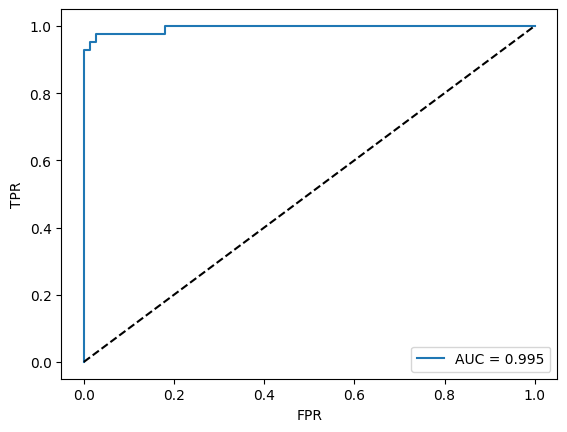

In [8]:
y_scores = svc.decision_function(X_test)
fpr, tpr, _ = roc_curve(y_test, y_scores)
auc = roc_auc_score(y_test, y_scores)

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.show()

## Parte (g): Optimización de hiperparámetros

In [9]:
param_grid = {
    "kernel": ["linear", "poly", "rbf", "sigmoid"],
    "C": [0.1, 1, 10],
    "class_weight": ["balanced", None, {0:1, 1:5}]
}

grid = GridSearchCV(SVC(), param_grid, cv=5, scoring="f1", n_jobs=-1)
grid.fit(X_train, y_train)

print("Mejores parámetros:", grid.best_params_)

best_svc = grid.best_estimator_
y_pred_best = best_svc.predict(X_test)

# Metricas conjunto de entrenamiento
print(metrics_report(y_train, best_svc.predict(X_train)))
# AUC entrenamiento
print("AUC entrenamiento:")
y_scores_train = best_svc.decision_function(X_train)
auc_train = roc_auc_score(y_train, y_scores_train)
fpr_train, tpr_train, _ = roc_curve(y_train, y_scores_train)
print(f"AUC entrenamiento: {auc_train:.4f}")

# Metricas conjunto de prueba
print(metrics_report(y_test, y_pred_best))
print("AUC prueba:")
auc_test = roc_auc_score(y_test, best_svc.decision_function(X_test))
fpr_test, tpr_test, _ = roc_curve(y_test, best_svc.decision_function(X_test))
print(f"AUC prueba: {auc_test:.4f}")

Mejores parámetros: {'C': 1, 'class_weight': None, 'kernel': 'rbf'}
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       285
           1       1.00      0.96      0.98       170

    accuracy                           0.99       455
   macro avg       0.99      0.98      0.99       455
weighted avg       0.99      0.99      0.99       455

AUC: 0.9824
{'Accuracy': 0.9868131868131869, 'Precision': 1.0, 'Recall (Sensibilidad)': 0.9647058823529412, 'Specificity': np.float64(1.0), 'F1-score': 0.9820359281437125, 'FPR': np.float64(0.0), 'FNR': np.float64(0.03529411764705882), 'TP': np.int64(164), 'TN': np.int64(285), 'FP': np.int64(0), 'FN': np.int64(6)}
AUC entrenamiento:
AUC entrenamiento: 0.9976
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98   

# Parte (i): Modeloado sobre proyecciones 2D

In [88]:
# Cargar datos
df = pd.read_csv("data.csv")  
# variable diagnosis a dummy binario
df["diagnosis"] = df["diagnosis"].map({"M": 1, "B": 0})

# Eliminar columna no informativa
df = df.drop(columns=['Unnamed: 32', 'id'])

X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

In [89]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Estandarizar
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

In [90]:
reducers = {
    "PCA": PCA(n_components=2),
    "UMAP": umap.UMAP(n_components=2, random_state=42),
    "Isomap": Isomap(n_components=2)
}

# --- 3. Grilla de hiperparámetros ---
param_grid = {
    "kernel": ["linear", "poly", "rbf", "sigmoid"],
    "C": [0.1, 1, 10],
    "class_weight": ["balanced", None, {0: 1, 1: 5}],
}

In [91]:
def evaluate_projection(name, reducer, X_train, X_test):
    print(f"Ejecutando proyección: {name}")
    # Ajustar proyección en entrenamiento y aplicar en prueba
    X_train_proj = reducer.fit_transform(X_train)
    X_test_proj = reducer.transform(X_test)
    
    grid = GridSearchCV(SVC(), param_grid, cv=5, scoring="f1", n_jobs=-1)
    grid.fit(X_train_proj, y_train)
    best_model = grid.best_estimator_
    
    # Predicciones
    y_pred = best_model.predict(X_test_proj)
    y_scores = best_model.decision_function(X_test_proj)
    
    # Métricas
    auc = roc_auc_score(y_test, y_scores)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    return {
        "Proyección": name,
        "Mejores Parámetros": grid.best_params_,
        "AUC": round(auc, 4),
        "Accuracy": round(acc, 4),
        "F1-Score": round(f1, 4)
    }

In [92]:
results = []

In [93]:
# Sobre datos estandarizados
for name, reducer in reducers.items():
    print("Utilizando datos escalados")
    results.append(evaluate_projection(f"{name}_std", reducer, X_train_std, X_test_std))

Utilizando datos escalados
Ejecutando proyección: PCA_std
Utilizando datos escalados
Ejecutando proyección: UMAP_std


c:\Users\pbast\Desktop\Universidad\VIV Semestre\Aprendizaje de Máquinas\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Utilizando datos escalados
Ejecutando proyección: Isomap_std


In [94]:
# Sobre datos originales
for name, reducer in reducers.items():
    print("Utilizando datos originales")
    results.append(evaluate_projection(f"{name}_original", reducer, X_train, X_test))

Utilizando datos originales
Ejecutando proyección: PCA_original
Utilizando datos originales
Ejecutando proyección: UMAP_original
Utilizando datos originales
Ejecutando proyección: Isomap_original


In [95]:
# --- 6. Resultados finales ---
df_results = pd.DataFrame(results)
display(df_results)

,Proyección,Mejores Parámetros,AUC,Accuracy,F1-Score
0,PCA_std,"{'C': 1, 'class_weight': None, 'kernel': 'line...",0.9964,0.9474,0.9250
1,UMAP_std,"{'C': 1, 'class_weight': 'balanced', 'kernel':...",0.9927,0.9561,0.9383
2,Isomap_std,"{'C': 10, 'class_weight': None, 'kernel': 'lin...",0.9924,0.9298,0.8974
3,PCA_original,"{'C': 1, 'class_weight': 'balanced', 'kernel':...",0.9825,0.9123,0.8684
4,UMAP_original,"{'C': 0.1, 'class_weight': None, 'kernel': 'rbf'}",0.9722,0.8860,0.8219
5,Isomap_original,"{'C': 0.1, 'class_weight': None, 'kernel': 'li...",0.9673,0.8772,0.8108


In [106]:
df_results["Mejores Parámetros"][5]

{'C': 0.1, 'class_weight': None, 'kernel': 'linear'}

## Parte (j): Impacto del escalado

In [18]:
df = pd.read_csv("data.csv")
df["diagnosis"] = df["diagnosis"].map({"M": 1, "B": 0})
df = df.drop(columns=["id", "Unnamed: 32"], errors="ignore")

X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scalers = {
    "StandardScaler": StandardScaler(),
    "RobustScaler": RobustScaler()
}

# Hiperparámetros óptimos (parte g)
best_params = {
    "C": 10,
    "kernel": "rbf",
    "class_weight": None
}

In [19]:
def evaluate_svc(X_train, X_test, y_train, y_test, params):
    model = SVC(**params, probability=True, random_state=42)
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    y_score_train = model.decision_function(X_train)
    y_score_test = model.decision_function(X_test)
    return {
        "AUC_train": roc_auc_score(y_train, y_score_train),
        "AUC_test": roc_auc_score(y_test, y_score_test),
        "Acc_train": accuracy_score(y_train, y_pred_train),
        "Acc_test": accuracy_score(y_test, y_pred_test),
        "F1_train": f1_score(y_train, y_pred_train),
        "F1_test": f1_score(y_test, y_pred_test)
    }

In [20]:
results = {}

In [21]:
for name, scaler in scalers.items():
    print(f"Usando {name}")
    # Escalar por separado para evitar Data Leakage
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    metrics = evaluate_svc(X_train_scaled, X_test_scaled, y_train, y_test, best_params)
    results[name] = metrics

Usando StandardScaler
Usando RobustScaler


In [22]:
df_results = pd.DataFrame(results).T
display(df_results)

,AUC_train,AUC_test,Acc_train,Acc_test,F1_train,F1_test
StandardScaler,1.000000,0.992725,0.989011,0.973684,0.985075,0.962963
RobustScaler,0.999959,0.993717,0.989011,0.973684,0.985075,0.962963


In [23]:
param_grid = {
    "kernel": ["linear", "poly", "rbf", "sigmoid"],
    "C": [0.1, 1, 10],
    "class_weight": ["balanced", None, {0: 1, 1: 5}]
}

for name, scaler in scalers.items():
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    grid = GridSearchCV(SVC(), param_grid, cv=5, scoring="f1", n_jobs=-1)
    grid.fit(X_train_scaled, y_train)
    print(f"\n--- {name} ---")
    print("Mejores parámetros:", grid.best_params_)
    print("Mejor F1 (CV):", grid.best_score_)
    
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test_scaled)
    y_score = best_model.decision_function(X_test_scaled)
    
    auc = roc_auc_score(y_test, y_score)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    print(f"AUC_test={auc:.6f}, Acc_test={acc:.6f}, F1_test={f1:.6f}")


--- StandardScaler ---
Mejores parámetros: {'C': 1, 'class_weight': None, 'kernel': 'rbf'}
Mejor F1 (CV): 0.966960456423372
AUC_test=0.994709, Acc_test=0.973684, F1_test=0.962963

--- RobustScaler ---
Mejores parámetros: {'C': 10, 'class_weight': None, 'kernel': 'rbf'}
Mejor F1 (CV): 0.961928465492458
AUC_test=0.993717, Acc_test=0.973684, F1_test=0.962963


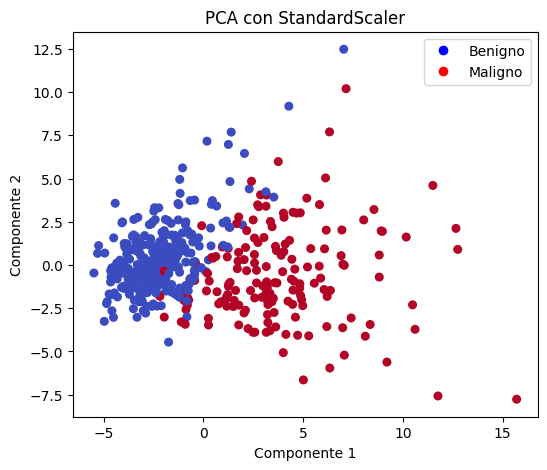

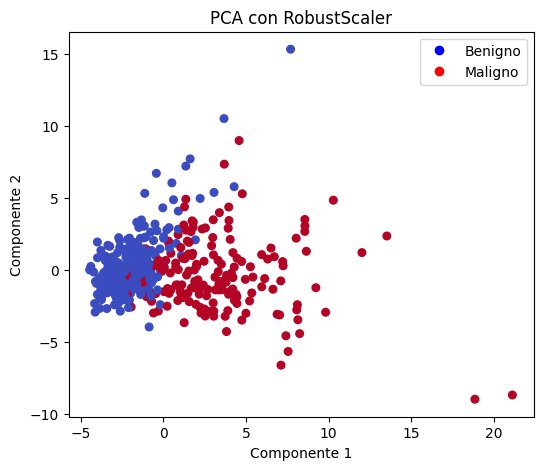

In [26]:
pca = PCA(n_components=2)

for name, scaler in scalers.items():
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    plt.figure(figsize=(6,5))
    plt.scatter(X_train_pca[:,0], X_train_pca[:,1], c=y_train, cmap="coolwarm", s=30)
    plt.title(f"PCA con {name}")
    plt.xlabel("Componente 1")
    plt.ylabel("Componente 2")
    # leyenda (solo azul y rojo)
    plt.legend(handles=[
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=8, label='Benigno'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label='Maligno')
    ])
    plt.show()